In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
runs = pd.read_csv("wandb_export_2024-07-31T12_31_42.587-04_00.csv")

In [3]:
metric_cols = [
    "Bt_mae",
    "Bt_r2",
    "Bt_rmse",
    "Bx_mae",
    "Bx_r2",
    "Bx_rmse",
    "By_mae",
    "By_r2",
    "By_rmse",
    "Bz_mae",
    "Bz_r2",
    "Bz_rmse",
    "Density_mae",
    "Density_r2",
    "Density_rmse",
    "Speed_mae",
    "Speed_r2",
    "Speed_rmse",
    "Temperature_mae",
    "Temperature_r2",
    "Temperature_rmse",
]
metric_weights = np.ones(len(metric_cols))

In [4]:
sel_metrics = runs[metric_cols]
scaler = MinMaxScaler(feature_range=(0, 1))
scaler_metrics = scaler.fit_transform(sel_metrics)
for i, col in enumerate(metric_cols):
    if "r2" in col.split("_"):
        scaler_metrics[:, i] = scaler_metrics[:, i]  # ensure we are maximizing r2
    else:
        scaler_metrics[:, i] = (
            1 - scaler_metrics[:, i]
        )  # ensure we are minimizing the rest
scaler_metrics = scaler_metrics * metric_weights

In [5]:
scaler_metrics = pd.DataFrame(data=scaler_metrics, columns=metric_cols)
scaler_metrics["Mean_Metric"] = scaler_metrics.mean(axis=1)
scaler_metrics["Name"] = runs["Name"]

In [6]:
scaler_metrics = scaler_metrics.sort_values(by="Mean_Metric", ascending=False)

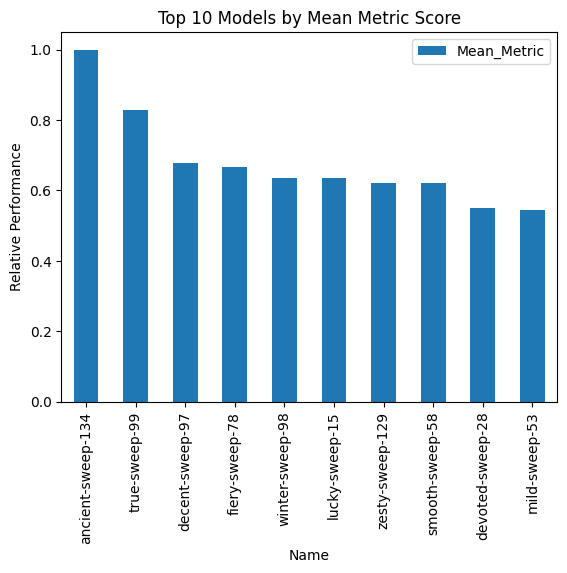

In [7]:
fig, ax = plt.subplots()
scaler_metrics[:10].plot(kind="bar", x="Name", y="Mean_Metric", ax=ax)
plt.xticks(rotation=90)
plt.ylabel("Relative Performance")
plt.title("Top 10 Models by Mean Metric Score")
plt.show()